# Modelagem, Treinamento e Avaliação

Este notebook executa e discute a etapa de modelagem do dataset **20 Fonts Classification**. A proposta é acompanhar os resultados conforme eles aparecem: primeiro entendemos os hiperparâmetros, depois analisamos o treino, comparamos os modelos, avaliamos as métricas por classe e, por fim, interpretamos as confusões mais relevantes.

A análise exploratória completa fica no notebook `01_analise_exploratoria_dados.ipynb`.

## 1. Configuração do ambiente

A célula abaixo localiza a raiz do projeto, confere se o kernel possui TensorFlow e importa o pipeline principal. Ela foi escrita para funcionar tanto quando o Jupyter é aberto na pasta raiz do projeto quanto quando é aberto diretamente na pasta `notebooks/`.

In [1]:
from pathlib import Path
from types import SimpleNamespace
import importlib
import json
import sys

# Encontra a raiz do projeto procurando pelo script principal.
ROOT = Path.cwd()
while not (ROOT / "src" / "font_classification.py").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("Não encontrei src/font_classification.py. Abra o notebook dentro do projeto.")
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))

PROJECT_PYTHON = ROOT / ".venv" / ("Scripts/python.exe" if sys.platform.startswith("win") else "bin/python")

def require_module(module_name, package_name=None):
    package_name = package_name or module_name
    try:
        __import__(module_name)
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError(
            f"O pacote '{package_name}' não está instalado no kernel atual.\n"
            f"Kernel atual: {sys.executable}\n"
            f"Ambiente do projeto esperado: {PROJECT_PYTHON}\n"
            "Selecione o kernel 'Python (.venv trabalho-redes-neurais)' ou instale as dependências no kernel atual com:\n"
            f"  {sys.executable} -m pip install -r \"{ROOT / 'requirements.txt'}\"\n"
            "Depois reinicie o kernel e execute o notebook desde o início."
        ) from exc

if sys.version_info >= (3, 13):
    raise RuntimeError(
        "O TensorFlow 2.16.2 usado neste projeto não é compatível com Python 3.13 ou superior.\n"
        f"Kernel atual: {sys.executable}\n"
        f"Versão atual: {sys.version.split()[0]}\n"
        f"Use o kernel da .venv do projeto, testado com Python 3.11: {PROJECT_PYTHON}"
    )

require_module("pandas")
require_module("IPython")
require_module("tensorflow")

import pandas as pd
from IPython.display import Image, display
import tensorflow as tf

import font_classification

# Força o Jupyter a usar a versão mais recente do arquivo .py.
# Isso evita continuar executando uma versão antiga que estava em cache no kernel.
font_classification = importlib.reload(font_classification)
run_pipeline = font_classification.run_pipeline

DATASET_DIR = ROOT / "dataset" / "20_fonts_classification"
OUTPUT_DIR = ROOT / "outputs"

print(f"Raiz do projeto: {ROOT}")
print(f"Dataset: {DATASET_DIR}")
print(f"TensorFlow: {tf.__version__}")

Raiz do projeto: c:\Users\jvict\OneDrive\Documentos\Projetos\trabalho-redes-neurais
Dataset: c:\Users\jvict\OneDrive\Documentos\Projetos\trabalho-redes-neurais\dataset\20_fonts_classification
TensorFlow: 2.16.2


## 2. Estratégia de modelagem

A tarefa é uma classificação multiclasse: cada imagem deve ser associada a uma entre 20 fontes possíveis. Para avaliar o efeito da arquitetura, usamos três modelos:

- **MLP Keras**: baseline neural que recebe os pixels vetorizados. Ela aprende combinações não lineares, mas não preserva explicitamente a vizinhança espacial entre pixels.
- **CNN BatchNorm**: modelo convolucional principal. Ele mantém a imagem como tensor e usa filtros locais para capturar bordas, curvas, serifas, espessura de traço e espaçamento entre letras.
- **VGG16 Fine-tuning**: modelo pré-treinado em ImageNet. Primeiro treinamos apenas a cabeça classificadora; depois descongelamos as últimas camadas para ajuste fino ao domínio das fontes.

A comparação mostra se a preservação da estrutura espacial melhora o desempenho e se a transferência de aprendizado de imagens naturais ajuda em um domínio de palavras monocromáticas.


## 3. Hiperparâmetros do experimento

Os hiperparâmetros foram definidos para equilibrar três pontos: tempo de execução, estabilidade do treinamento e desempenho final. As imagens são reduzidas para `128 x 32` pixels, preservando o formato horizontal das palavras e mantendo mais detalhes tipográficos locais para a CNN.


In [ ]:
args = SimpleNamespace(
    dataset=DATASET_DIR,
    output=OUTPUT_DIR,
    image_width=128,
    image_height=32,
    seed=42,
    batch_size=256,
    mlp_epochs=24,
    cnn_epochs=24,
    vgg_head_epochs=8,
    vgg_finetune_epochs=16,
    mlp_lr=0.001,
    cnn_lr=0.001,
    vgg_head_lr=0.001,
    vgg_finetune_lr=0.00001,
    vgg_trainable_layers=4,
    vgg_weights="imagenet",
    patience=6,
)

args

- O tamanho `128 x 32` reduz a imagem original de `200 x 50`, mas preserva detalhes locais importantes para distinguir traços, curvas e serifas.
- O `batch_size=256` deixa o treinamento eficiente e mantém atualizações frequentes dos pesos.
- A MLP usa camadas densas com 256 e 128 neurônios, funcionando como baseline neural forte.
- A CNN usa blocos `Conv2D`, `BatchNormalization` e `MaxPooling2D`, preservando a estrutura espacial da imagem.
- A VGG16 Fine-tuning usa pesos pré-treinados em ImageNet e passa por duas fases: cabeça congelada e ajuste fino das últimas camadas.
- O `seed=42` garante reprodutibilidade: a divisão dos dados e a inicialização dos pesos podem ser repetidas.


## 4. Execução do pipeline

A célula abaixo executa o pipeline completo de modelagem: divisão estratificada, pré-processamento das imagens, treinamento dos modelos, avaliação no teste, geração de figuras, métricas e modelo salvo.

Durante a execução, observe as linhas de treinamento. Elas mostram `loss`, `accuracy`, `val_loss` e `val_accuracy` por época. Esses valores são a primeira evidência de como cada modelo está aprendendo.

In [3]:
# Executa o pipeline completo de treinamento e avaliação.
results = run_pipeline(args)

Carregando imagens de treino...
Carregando imagens de validação...
Carregando imagens de teste...
Treinando MLP Keras baseline...
Epoch 1/24
55/55 - 2s - 33ms/step - accuracy: 0.3024 - loss: 2.1334 - val_accuracy: 0.5850 - val_loss: 1.3388
Epoch 2/24
55/55 - 1s - 12ms/step - accuracy: 0.5839 - loss: 1.2262 - val_accuracy: 0.7777 - val_loss: 0.8134
Epoch 3/24
55/55 - 1s - 11ms/step - accuracy: 0.7425 - loss: 0.7847 - val_accuracy: 0.8583 - val_loss: 0.5229
Epoch 4/24
55/55 - 1s - 15ms/step - accuracy: 0.8249 - loss: 0.5396 - val_accuracy: 0.8943 - val_loss: 0.3755
Epoch 5/24
55/55 - 1s - 17ms/step - accuracy: 0.8806 - loss: 0.3837 - val_accuracy: 0.9160 - val_loss: 0.2814
Epoch 6/24
55/55 - 1s - 17ms/step - accuracy: 0.9086 - loss: 0.2883 - val_accuracy: 0.9243 - val_loss: 0.2394
Epoch 7/24
55/55 - 1s - 15ms/step - accuracy: 0.9310 - loss: 0.2278 - val_accuracy: 0.9423 - val_loss: 0.1952
Epoch 8/24
55/55 - 1s - 14ms/step - accuracy: 0.9423 - loss: 0.1911 - val_accuracy: 0.9420 - val_los

Depois que a célula termina, já temos alguns sinais importantes:

- Se a acurácia de treino sobe e a de validação também sobe, o modelo está aprendendo padrões úteis.
- Se a acurácia de treino sobe muito e a validação estaciona ou piora, há indício de overfitting.
- Se ambas ficam baixas, o modelo pode estar subajustado ou os hiperparâmetros podem estar inadequados.

A próxima célula lê as métricas salvas e resume numericamente o que aconteceu no treinamento.

In [4]:
metrics = json.loads((OUTPUT_DIR / "metrics.json").read_text(encoding="utf-8"))

split_sizes = metrics["dataset"]["split_sizes"]
model_keys = ["mlp", "cnn_batchnorm", "vgg16"]
histories = {key: pd.DataFrame(metrics["models"][key]["history"]) for key in model_keys}

print("Tamanho dos conjuntos:")
for split_name, split_size in split_sizes.items():
    print(f"- {split_name}: {split_size} imagens")

training_summary = []
for key in model_keys:
    model_metrics = metrics["models"][key]
    history = histories[key]
    best_epoch = int(history.sort_values("val_accuracy", ascending=False).iloc[0]["epoch"])
    training_summary.append({
        "modelo": model_metrics["label"],
        "épocas": model_metrics["epochs_ran"],
        "melhor_época": best_epoch,
        "melhor_val_accuracy": model_metrics["best_val_accuracy"],
        "parametros": model_metrics["parameter_count"],
    })

training_summary = pd.DataFrame(training_summary)
display(training_summary.round(4))


Tamanho dos conjuntos:
- train: 14000 imagens
- val: 3000 imagens
- test: 3000 imagens


,modelo,épocas,melhor_época,melhor_val_accuracy,parametros
0,MLP Keras,24,24,0.9743,1084308
1,CNN BatchNorm,24,19,0.9933,1144852
2,VGG16 Fine-tuning,24,23,0.9277,14782932


A divisão dos dados segue a proporção 70/15/15, então o teste fica separado até o final. Isso é importante porque o teste simula imagens que o modelo nunca viu durante o ajuste dos pesos nem durante a escolha do melhor modelo.

A acurácia de validação é usada para comparar épocas e escolher o melhor checkpoint. Dessa forma, a decisão não é tomada pela acurácia de treino, que costuma ser otimista, mas por um conjunto separado que mede melhor a capacidade de generalização.

## 5. Curvas de treinamento

As curvas mostram a evolução da perda e da acurácia ao longo das épocas. Elas são úteis para avaliar aprendizado, estabilidade e possível overfitting.

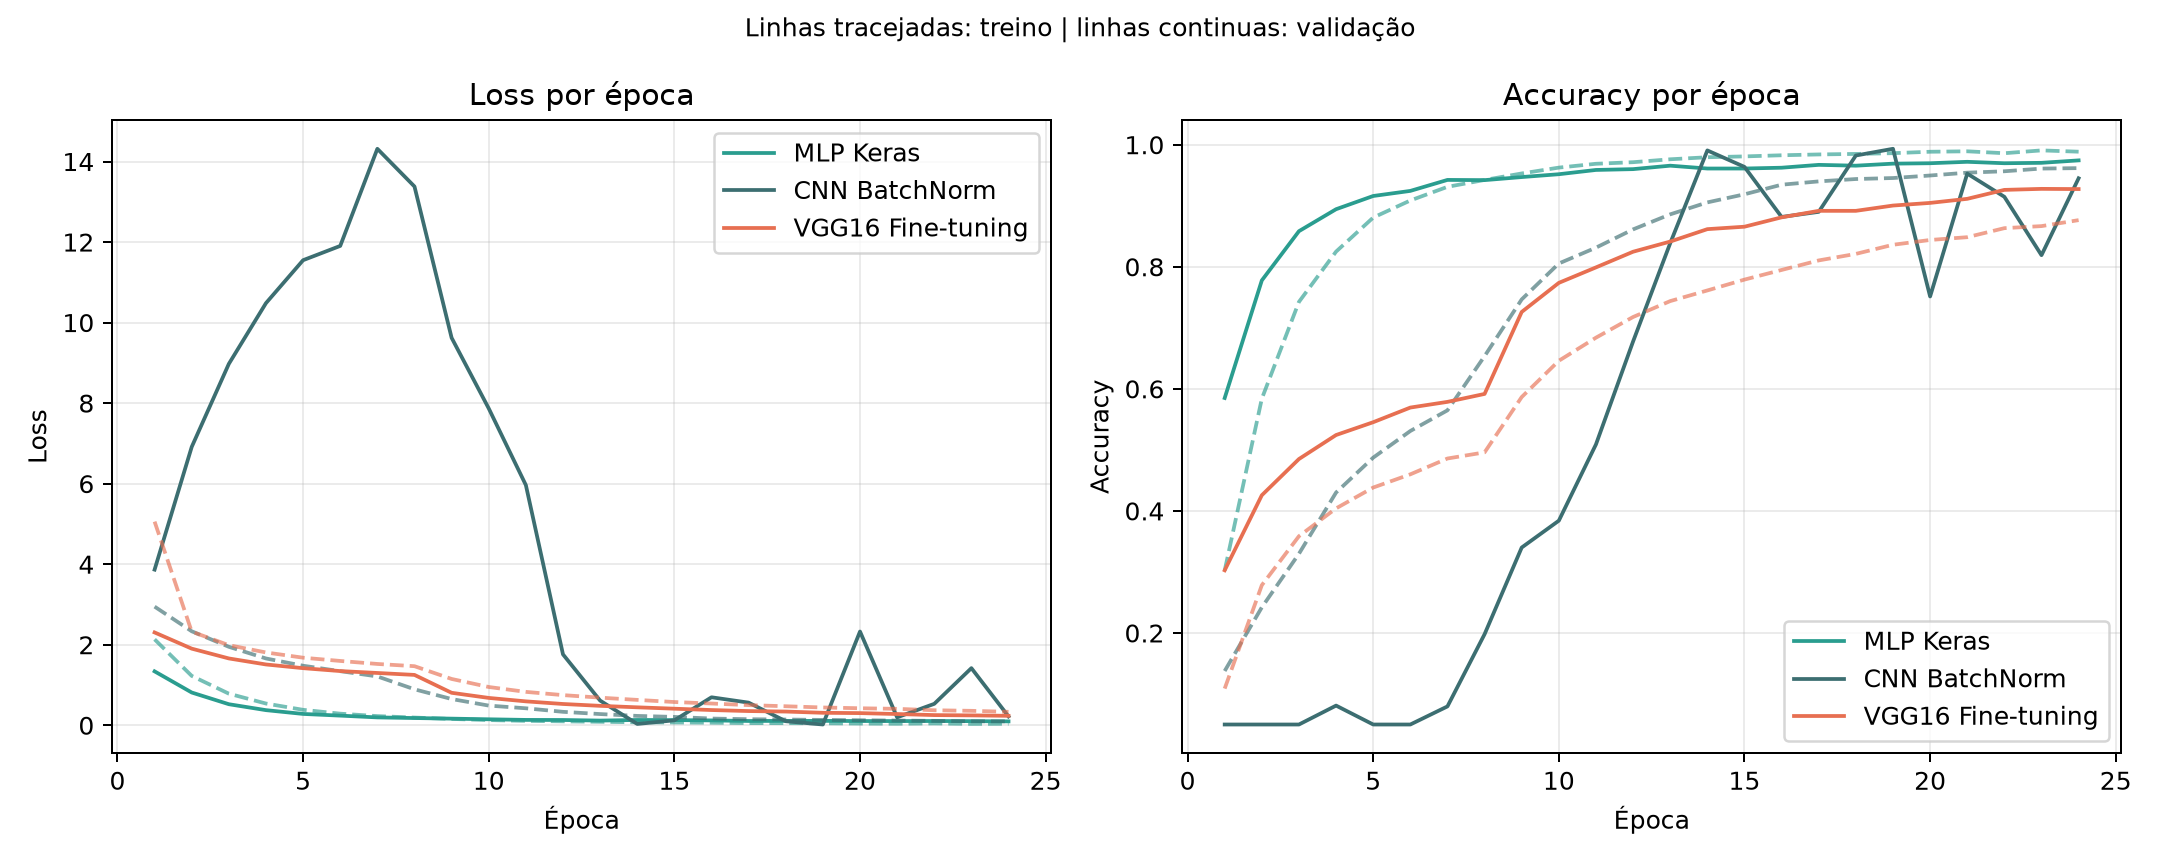

In [5]:
display(Image(filename=str(OUTPUT_DIR / "figures" / "03_curvas_treinamento.png")))

In [6]:
curve_summary = pd.DataFrame([
    {
        "modelo": metrics["models"][key]["label"],
        "loss_treino_inicial": history.iloc[0]["train_loss"],
        "loss_treino_final": history.iloc[-1]["train_loss"],
        "acc_treino_final": history.iloc[-1]["train_accuracy"],
        "loss_validação_final": history.iloc[-1]["val_loss"],
        "acc_validação_final": history.iloc[-1]["val_accuracy"],
        "tempo_médio_época_s": history["epoch_seconds"].mean(),
    }
    for key, history in histories.items()
])

display(curve_summary.round(4))


,modelo,loss_treino_inicial,loss_treino_final,acc_treino_final,loss_validação_final,acc_validação_final,tempo_médio_época_s
0,MLP Keras,2.1334,0.0363,0.9886,0.0966,0.9743,0.7972
1,CNN BatchNorm,2.9464,0.0982,0.9616,0.2194,0.9450,30.9959
2,VGG16 Fine-tuning,5.0574,0.3343,0.8764,0.2345,0.9273,126.0007


O comportamento esperado é a queda da `loss` e o aumento da `accuracy`. Quando isso ocorre simultaneamente em treino e validação, significa que o modelo não está apenas memorizando o conjunto de treino, mas também aprendendo padrões que aparecem em dados separados.

Após o treinamento da MLP, observa-se que ela já atinge desempenho alto: `accuracy=0.9693` no teste. Isso demonstra que, mesmo sem explorar explicitamente a estrutura espacial das imagens, uma rede densa consegue distinguir grande parte das fontes a partir dos pixels vetorizados.

Após o treinamento da CNN BatchNorm, o ganho fica claro: o modelo chega a `accuracy=0.9930` e `macro_f1=0.9930`, superando a MLP. Esse resultado é coerente com o problema, pois filtros convolucionais capturam padrões locais das letras, como serifas, curvaturas, espessura dos traços e espaçamentos.

Após o treinamento da VGG16 Fine-tuning, o desempenho fica em `accuracy=0.9287` e `macro_f1=0.9280`. O modelo pré-treinado melhora com o ajuste fino, mas ainda fica abaixo da CNN, indicando que o conhecimento transferido da ImageNet não se mostrou ideal para o domínio de fontes tipográficas monocromáticas.


## 6. Comparação dos modelos no teste

Agora avaliamos os modelos no conjunto de teste. Esse é o resultado mais importante, porque o teste não foi usado para treinar nem para escolher checkpoints.

In [7]:
comparison = pd.DataFrame([
    {
        "modelo": metrics["models"][key]["label"],
        "val_accuracy": metrics["models"][key]["best_val_accuracy"],
        **metrics["models"][key]["test_summary"],
        "épocas": metrics["models"][key]["epochs_ran"],
    }
    for key in model_keys
])

display(comparison.round(4))

mlp_acc = comparison.loc[comparison["modelo"] == "MLP Keras", "accuracy"].iloc[0]
cnn_acc = comparison.loc[comparison["modelo"] == "CNN BatchNorm", "accuracy"].iloc[0]
vgg_acc = comparison.loc[comparison["modelo"] == "VGG16 Fine-tuning", "accuracy"].iloc[0]

print(f"Ganho absoluto de accuracy da CNN sobre a MLP: {(cnn_acc - mlp_acc):.4f}")
print(f"Redução relativa do erro da CNN sobre a MLP: {((1 - mlp_acc) - (1 - cnn_acc)) / (1 - mlp_acc):.2%}")
print(f"Diferença de accuracy da CNN sobre a VGG16 Fine-tuning: {(cnn_acc - vgg_acc):.4f}")


,modelo,val_accuracy,accuracy,macro_f1,weighted_f1,épocas
0,MLP Keras,0.9743,0.9693,0.9693,0.9693,24
1,CNN BatchNorm,0.9933,0.9930,0.9930,0.9930,24
2,VGG16 Fine-tuning,0.9277,0.9287,0.9280,0.9280,24


Ganho absoluto de accuracy da CNN sobre a MLP: 0.0237
Redução relativa do erro da CNN sobre a MLP: 77.17%
Diferença de accuracy da CNN sobre a VGG16 Fine-tuning: 0.0643


A acurácia indica a proporção total de imagens classificadas corretamente. O macro F1 calcula a média do F1-score das classes dando o mesmo peso para cada fonte. Como o dataset é balanceado, `macro_f1` e `weighted_f1` tendem a ficar próximos.

A tabela acima mostra que a MLP Keras atingiu aproximadamente 96,93% de acurácia, funcionando como baseline neural forte. A CNN BatchNorm superou esse resultado ao preservar a estrutura espacial da imagem, chegando a 99,30% de acurácia e 99,30% de Macro F1.

A VGG16 Fine-tuning obteve `accuracy=0.9287` e `macro_f1=0.9280`. O resultado confirma que o ajuste fino permitiu adaptar parte das representações pré-treinadas, mas ainda ficou abaixo da MLP e da CNN. A interpretação mais provável é que a CNN própria está mais alinhada ao domínio simples e monocromático das fontes, enquanto a VGG16 traz representações aprendidas originalmente em imagens naturais.


## 7. Métricas por classe

A média geral é importante, mas pode esconder classes problemáticas. Por isso, analisamos `precision`, `recall`, `F1-score` e `support` para cada fonte.

In [8]:
class_report = pd.read_csv(OUTPUT_DIR / "classification_report_cnn_batchnorm.csv")
display(class_report.round(4))

,class,precision,recall,f1,support
0,Arial,1.0000,1.0000,1.0000,150
1,Bookman,1.0000,1.0000,1.0000,150
2,Calibri,0.9865,0.9733,0.9799,150
3,Candara,0.9739,0.9933,0.9835,150
4,CenturyGothic,1.0000,1.0000,1.0000,150
5,ComicSansMS,0.9675,0.9933,0.9803,150
6,CourierNew,1.0000,1.0000,1.0000,150
7,FranclinGothic,1.0000,1.0000,1.0000,150
8,Garamond,0.9868,1.0000,0.9934,150
9,Georgia,1.0000,1.0000,1.0000,150


In [9]:
best_classes = class_report.sort_values("f1", ascending=False).head(5)
worst_classes = class_report.sort_values("f1", ascending=True).head(5)

print("Cinco melhores classes por F1-score:")
display(best_classes[["class", "precision", "recall", "f1", "support"]].round(4))

print("Cinco classes com menor F1-score:")
display(worst_classes[["class", "precision", "recall", "f1", "support"]].round(4))

Cinco melhores classes por F1-score:


,class,precision,recall,f1,support
0,Arial,1.0,1.0,1.0,150
12,LucidaSans,1.0,1.0,1.0,150
17,TimesNewRoman,1.0,1.0,1.0,150
16,SegoeUI,1.0,1.0,1.0,150
4,CenturyGothic,1.0,1.0,1.0,150


Cinco classes com menor F1-score:


,class,precision,recall,f1,support
18,TrebuchetMS,0.9932,0.9667,0.9797,150
2,Calibri,0.9865,0.9733,0.9799,150
5,ComicSansMS,0.9675,0.9933,0.9803,150
11,Lobster,1.0000,0.9667,0.9831,150
3,Candara,0.9739,0.9933,0.9835,150


O `precision` responde: entre todas as imagens que o modelo disse serem de uma fonte, quantas realmente eram daquela fonte? Já o `recall` responde: entre todas as imagens reais daquela fonte, quantas o modelo conseguiu recuperar corretamente?

Classes com F1-score alto geralmente possuem traços mais distintivos ou menos parecidos com outras fontes. Fontes mais estilizadas, como cursivas ou com desenho muito característico, costumam ser mais fáceis de separar.

Classes com F1-score menor indicam fontes visualmente próximas de outras. Em classificação de fontes, isso é esperado principalmente entre fontes sem serifa, que compartilham proporções e traços parecidos. Nesses casos, mesmo humanos podem precisar olhar detalhes pequenos para diferenciar as fontes.

## 8. F1-score por classe

A figura abaixo ordena as classes pelo F1-score da CNN BatchNorm, que foi o melhor modelo do experimento. Ela facilita identificar rapidamente quais fontes permaneceram mais difíceis mesmo após o uso de uma arquitetura convolucional.


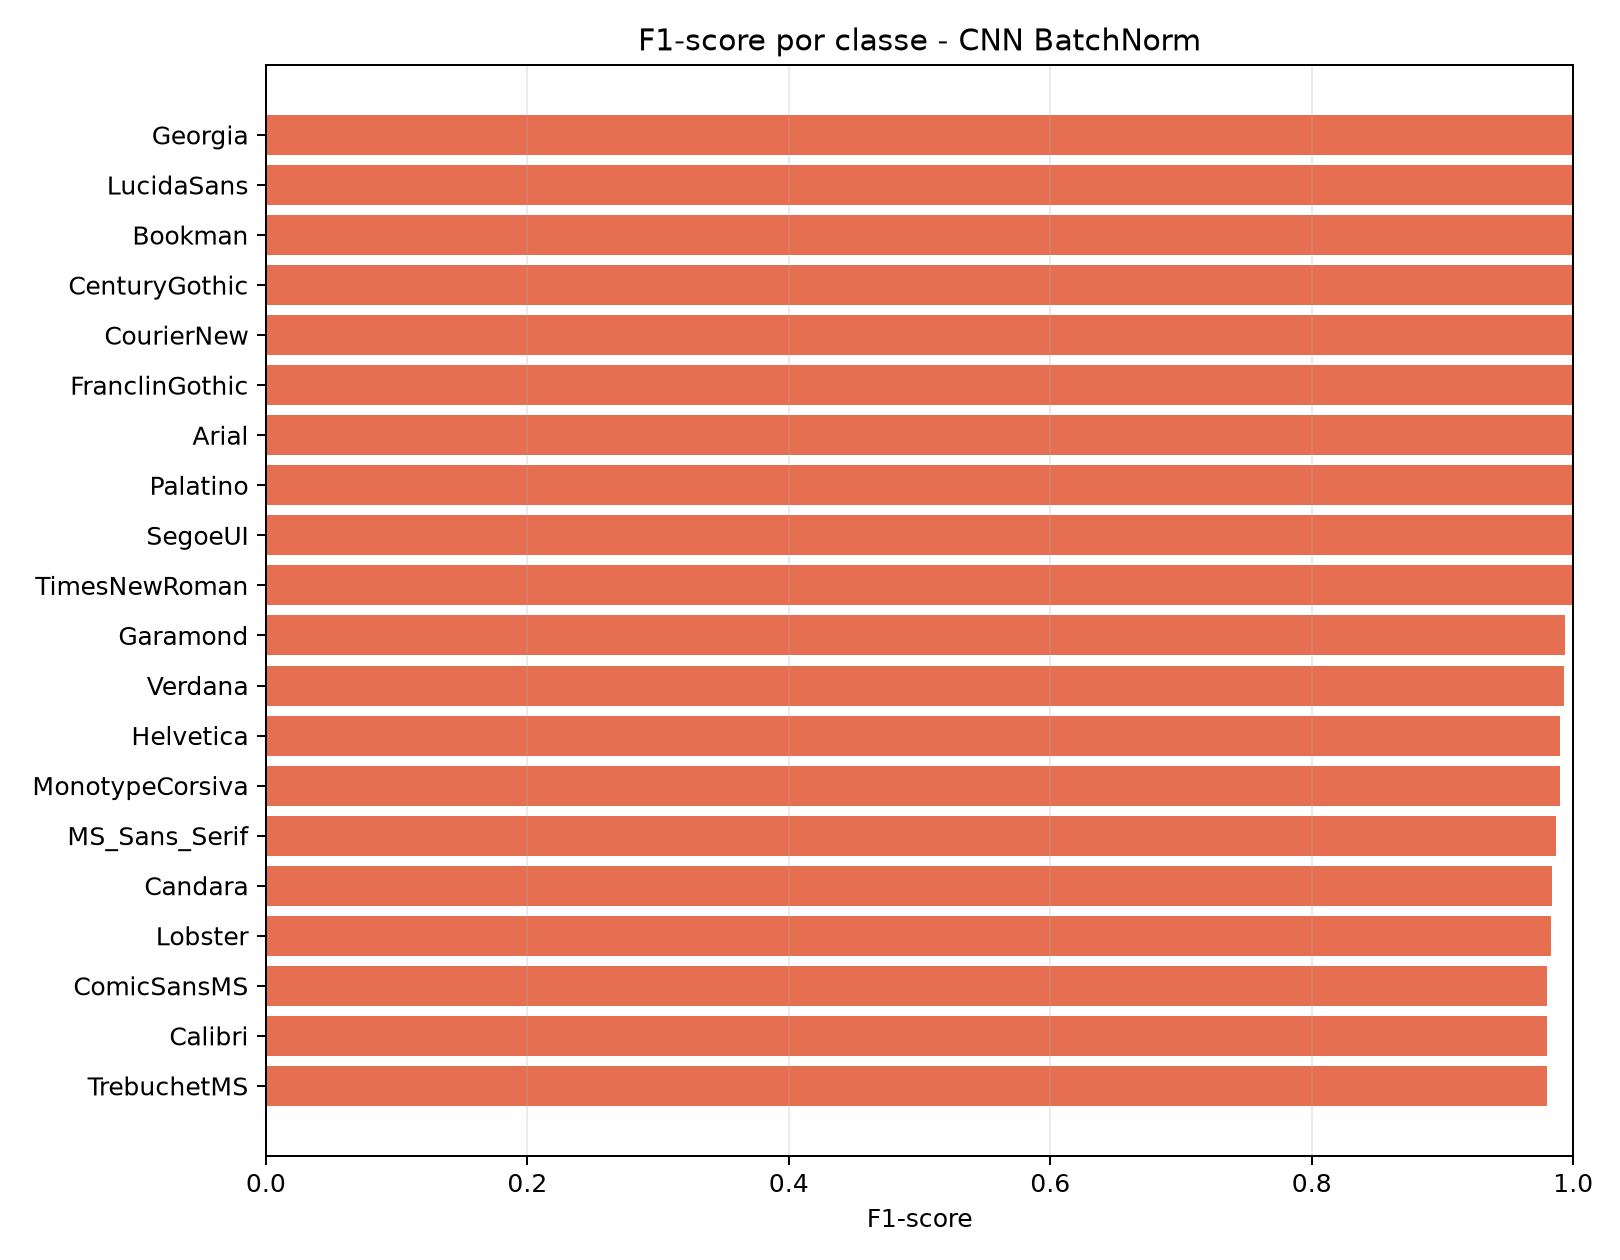

In [10]:
display(Image(filename=str(OUTPUT_DIR / "figures" / "05_f1_por_classe.png")))

O gráfico deixa claro se o desempenho está distribuído de forma homogênea. Se todas as barras ficam próximas, o modelo trata as classes de maneira equilibrada. Se algumas barras ficam muito abaixo, essas classes merecem investigação na matriz de confusão.

Neste problema, quedas pontuais de F1 tendem a indicar confusão visual entre famílias tipográficas semelhantes. Isso não significa necessariamente que o modelo falhou de forma aleatória; muitas vezes ele erra de maneira semanticamente compreensível, confundindo fontes com estruturas visuais parecidas.

## 9. Matriz de confusão

A matriz de confusão mostra, para cada classe real, como as previsões foram distribuídas. A diagonal representa acertos; valores fora da diagonal representam erros.

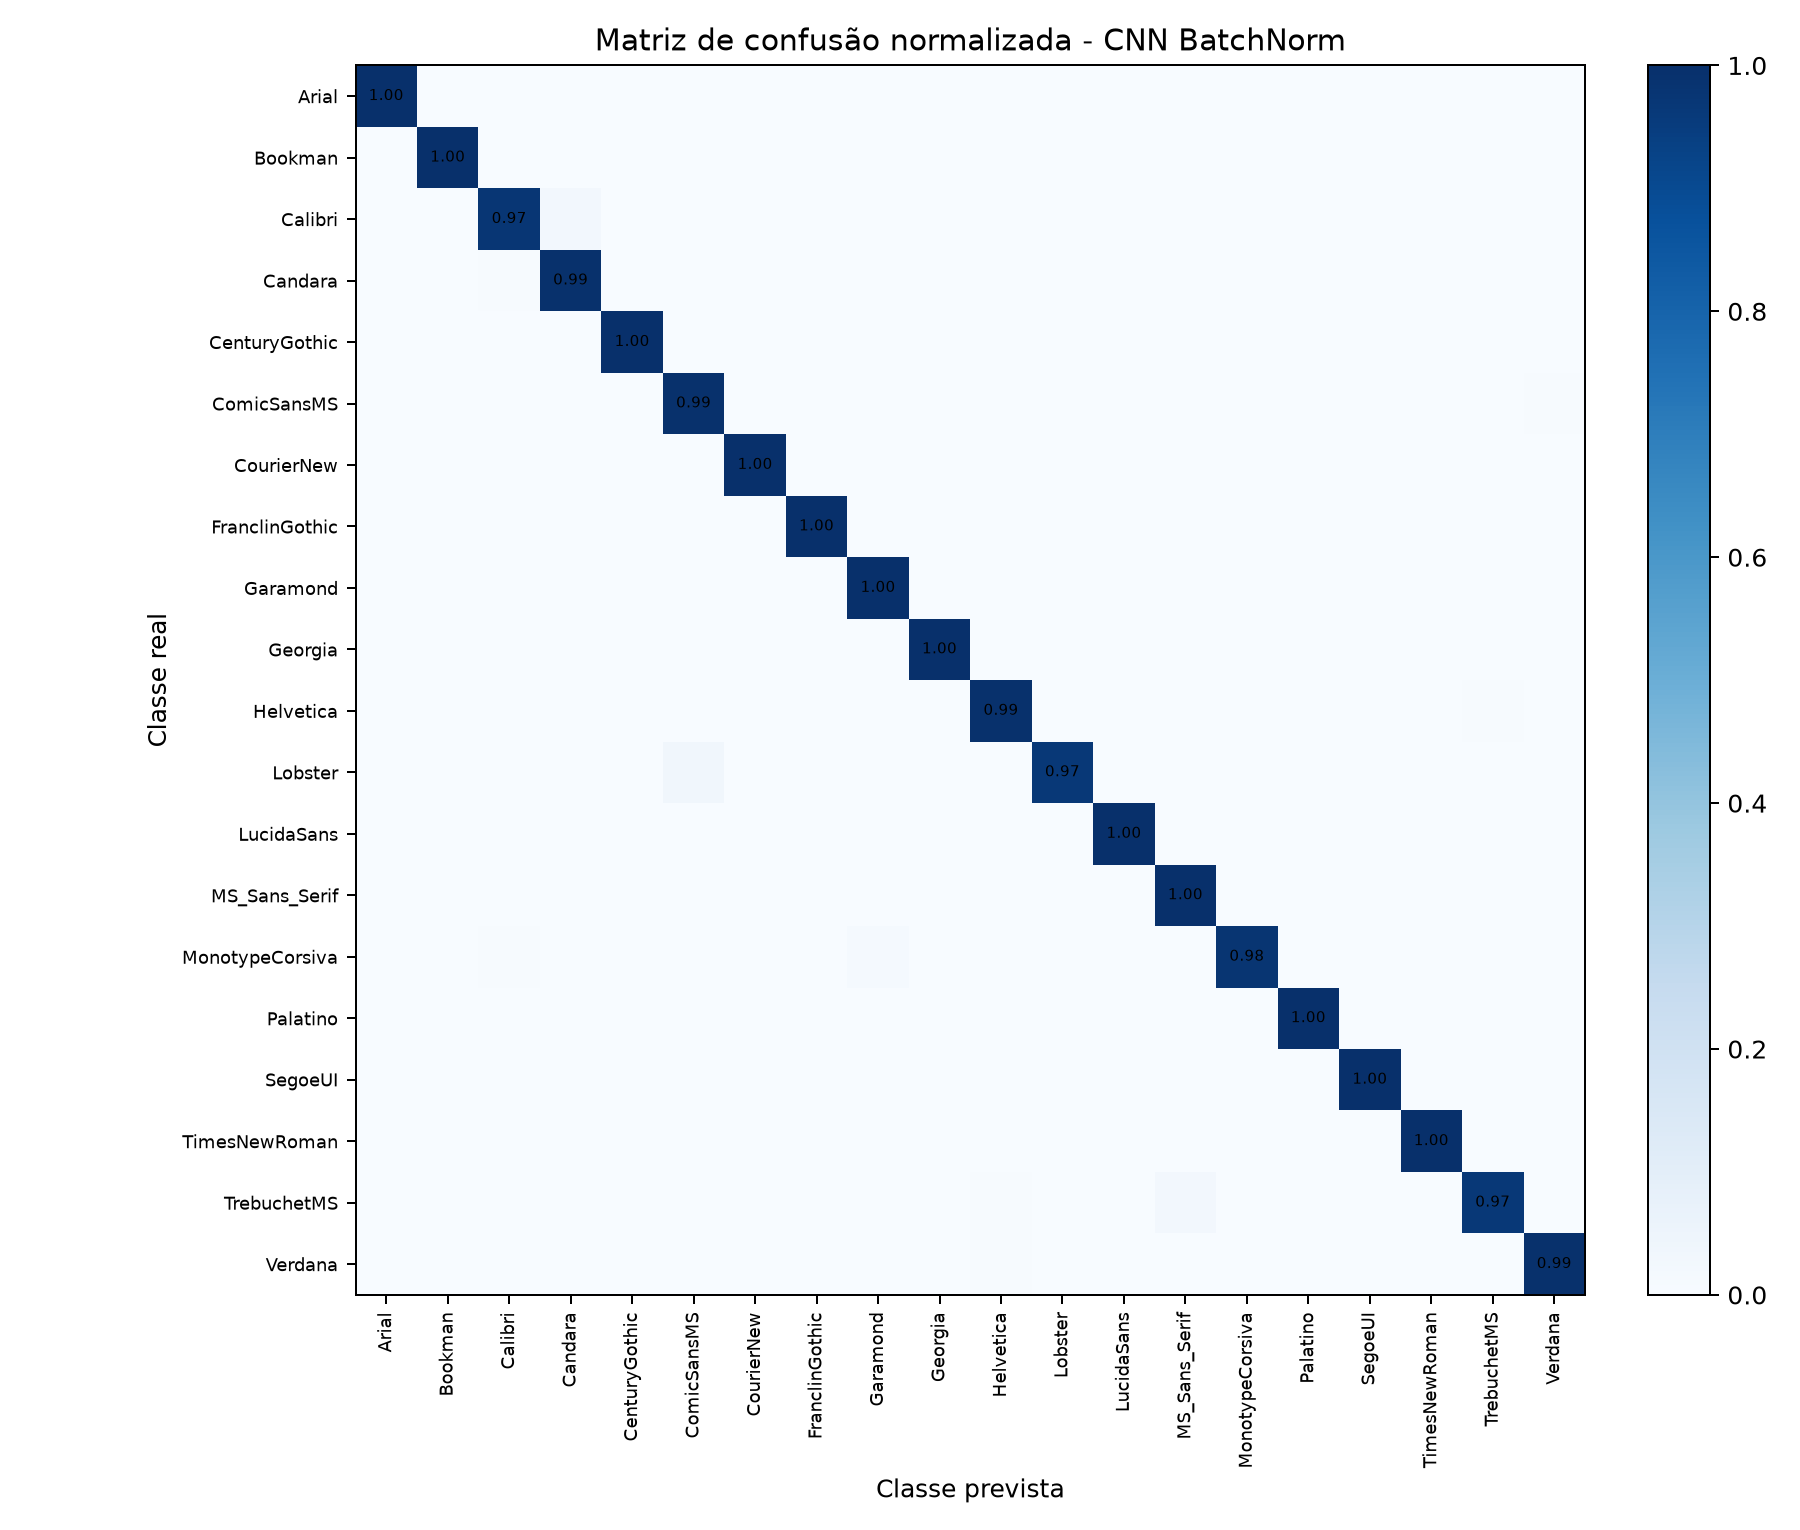

In [11]:
display(Image(filename=str(OUTPUT_DIR / "figures" / "04_matriz_confusao_cnn_batchnorm.png")))

In [12]:
confusion_matrix = pd.read_csv(OUTPUT_DIR / "confusion_matrix_cnn_batchnorm.csv", index_col=0)

per_class_errors = []
for class_name in confusion_matrix.index:
    total = confusion_matrix.loc[class_name].sum()
    correct = confusion_matrix.loc[class_name, class_name]
    errors = total - correct
    per_class_errors.append({
        "classe": class_name,
        "total": int(total),
        "acertos": int(correct),
        "erros": int(errors),
        "taxa_de_erro": errors / total,
    })

per_class_errors = pd.DataFrame(per_class_errors).sort_values("taxa_de_erro", ascending=False)
display(per_class_errors.head(10).round(4))

,classe,total,acertos,erros,taxa_de_erro
11,Lobster,150,145,5,0.0333
18,TrebuchetMS,150,145,5,0.0333
2,Calibri,150,146,4,0.0267
14,MonotypeCorsiva,150,147,3,0.0200
10,Helvetica,150,149,1,0.0067
19,Verdana,150,149,1,0.0067
5,ComicSansMS,150,149,1,0.0067
3,Candara,150,149,1,0.0067
6,CourierNew,150,150,0,0.0000
7,FranclinGothic,150,150,0,0.0000


A matriz de confusão é a parte mais interpretável da avaliação. Ela mostra não apenas quanto o modelo erra, mas **como** ele erra.

Quando uma classe tem muitos erros concentrados em uma única outra classe, isso sugere semelhança visual forte entre as duas fontes. Quando os erros ficam espalhados em várias classes, a fonte pode ter sinais menos consistentes ou o modelo pode não estar capturando bem seus padrões.

A tabela de taxa de erro por classe ajuda a priorizar a análise: as primeiras linhas indicam as fontes que mais precisam de atenção caso o objetivo seja melhorar o modelo.

## 10. Principais confusões

Agora listamos os pares de classes mais confundidos, ignorando a diagonal de acertos.

In [13]:
top_confusions = pd.DataFrame(metrics["models"]["cnn_batchnorm"]["top_confusions"])
display(top_confusions)

,true_class,predicted_class,count
0,Lobster,ComicSansMS,5
1,TrebuchetMS,MS_Sans_Serif,4
2,Calibri,Candara,4
3,MonotypeCorsiva,Garamond,2
4,Verdana,Helvetica,1
5,TrebuchetMS,Helvetica,1
6,Helvetica,TrebuchetMS,1
7,ComicSansMS,Verdana,1


As maiores confusões costumam envolver fontes com aparência próxima. Por exemplo, fontes sem serifa tendem a compartilhar linhas limpas, ausência de serifas e proporções parecidas. Já fontes cursivas ou decorativas normalmente possuem características mais marcantes, o que facilita a separação.

Esse tipo de erro é útil para propor melhorias. Mesmo com a CNN BatchNorm, que explora a vizinhança espacial entre pixels, ainda restam confusões em pares visualmente muito semelhantes. Isso indica que parte do erro está ligada à dificuldade intrínseca do domínio, e não apenas à escolha do modelo.


## 11. Artefatos finais da execução

Após a execução deste notebook, os principais arquivos gerados automaticamente são:

- `outputs/models/mlp_fonts_classifier.keras`: modelo MLP salvo.
- `outputs/models/cnn_batchnorm_fonts_classifier.keras`: melhor modelo usado para predição por padrão.
- `outputs/models/vgg16_fonts_classifier.keras`: modelo VGG16 com fine-tuning salvo.
- `outputs/metrics.json`: métricas consolidadas.
- `outputs/classification_report_cnn_batchnorm.csv`: métricas por classe do melhor modelo.
- `outputs/confusion_matrix_cnn_batchnorm.csv`: matriz de confusão do melhor modelo.
- `outputs/figures/`: gráficos usados na análise dos resultados.


## 12. Conclusão

A comparação mostra que a CNN BatchNorm apresenta o melhor desempenho entre os modelos avaliados. Na execução atual, a MLP Keras atingiu `accuracy=0.9693` e `macro_f1=0.9693`, enquanto a CNN BatchNorm alcançou `accuracy=0.9930` e `macro_f1=0.9930`. A MLP funciona como um baseline neural forte, mas a CNN melhora o resultado ao preservar a estrutura espacial da imagem.

Esse ganho é coerente com a natureza do problema. A classificação de fontes depende de padrões locais como espessura de traço, desenho das curvas, presença ou ausência de serifa e espaçamento visual dos caracteres. Filtros convolucionais são mais adequados para capturar esse tipo de sinal do que uma rede densa alimentada apenas por um vetor de pixels.

A VGG16 Fine-tuning foi usada para testar transferência de aprendizado com adaptação ao domínio. Ela obteve `accuracy=0.9287` e `macro_f1=0.9280` no teste. O resultado confirma que o fine-tuning ajudou bastante, especialmente porque a melhor validação saiu de `0.5917` na fase de cabeça congelada para `0.9277` após o ajuste fino, mas também mostra que a transferência a partir da ImageNet ainda ficou abaixo dos modelos treinados diretamente nas imagens tipográficas.

As métricas por classe e a matriz de confusão mostram que os erros restantes não são aleatórios. Eles se concentram principalmente entre fontes visualmente parecidas, como Calibri/Candara, Helvetica/TrebuchetMS e Arial/MS_Sans_Serif, além de alguns estilos com curvas decorativas.

Como melhoria futura, seria interessante testar aumento de dados controlado, busca sistemática de hiperparâmetros, diferentes quantidades de camadas descongeladas na VGG16 e avaliação com palavras ou imagens que não aparecem no conjunto original.
